##Credit Risk Assessment

## 1. Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading dataset

In [3]:
df = pd.read_csv('D:\game\Credit_risk\credit_risk_dataset.csv')

<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\Abhay Dixit\AppData\Local\Temp\ipykernel_2560\3058193386.py:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  df = pd.read_csv('D:\game\Credit_risk\credit_risk_dataset.csv')


In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA)

In [5]:
df.shape

(32581, 12)

In [7]:
# Checking datatypes of features
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [8]:
# Checking missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
# Analysing 'loan_status' as it is our target column
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

-> Class imbalance ( as 0 -> 25475,

 1 -> 7108 )

<Axes: xlabel='loan_status', ylabel='count'>

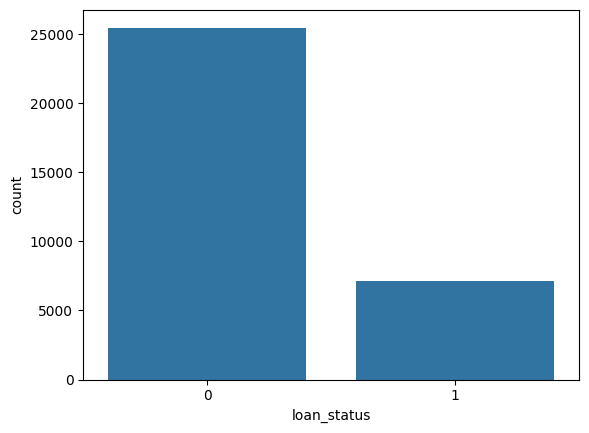

In [10]:
sns.countplot(x='loan_status', data=df)

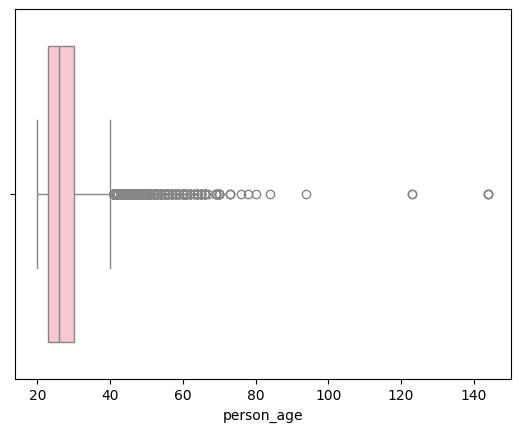

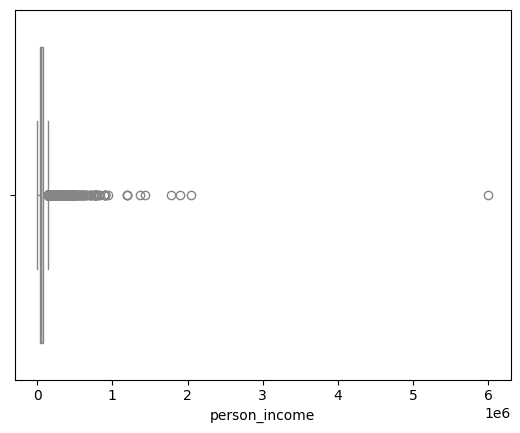

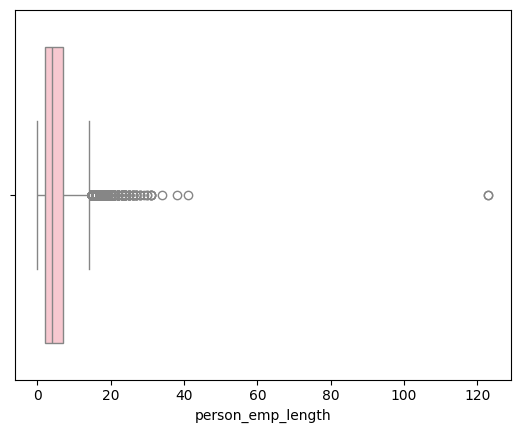

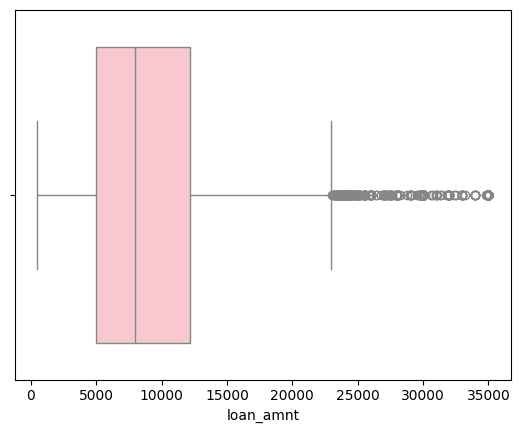

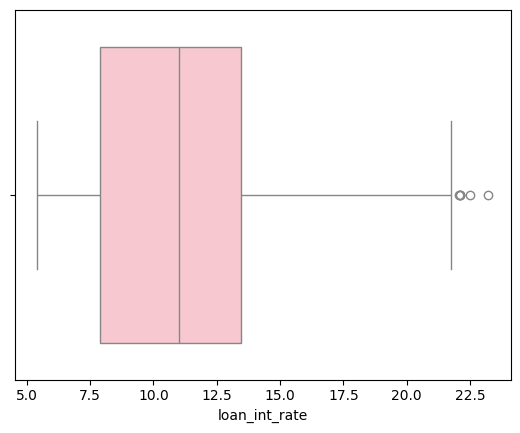

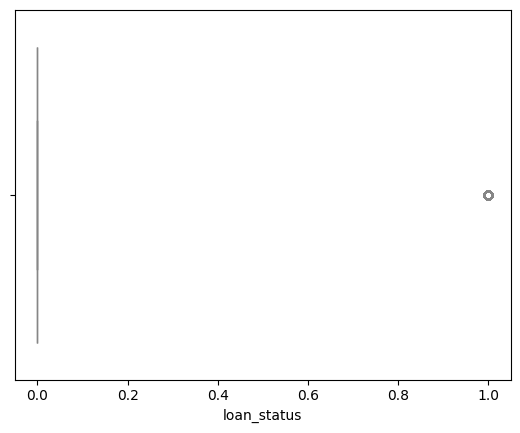

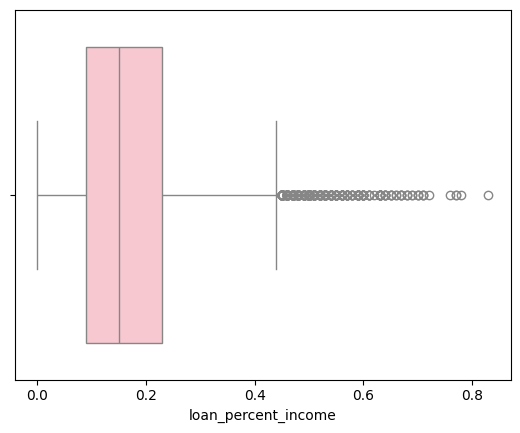

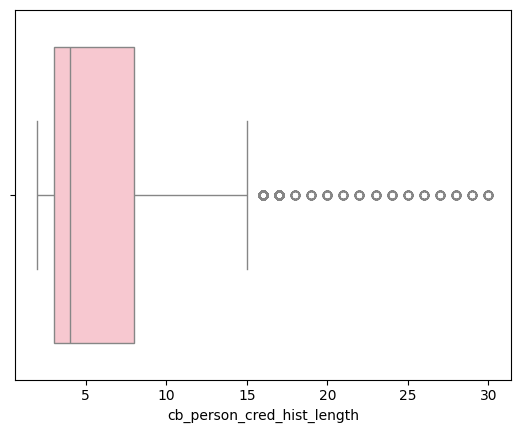

In [11]:
# extracting numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=i, data=df, color='pink')
  plt.show()


In [12]:
# looking for outliers in Age column
(df['person_age'] >100).sum()

np.int64(5)

In [13]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Correlation check

<Axes: >

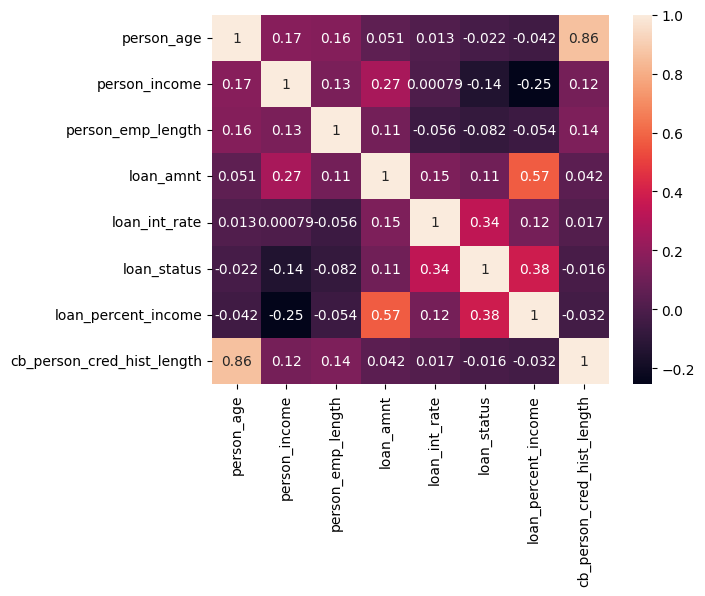

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data Validation & Outlier Handling

In [16]:
# making a copy of dataset
df_copy = df.copy()

In [17]:
df_copy.duplicated().sum()


np.int64(165)

In [18]:
print(f"Original Rows: {df_copy.shape[0]}")

Original Rows: 32581


In [19]:
# Removing Duplicated rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates: {df_copy.shape[0]}")

Rows after removing duplicates: 32416


In [20]:
# Removing outliers ( Age below 18 & above 100)
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# removing employment length ( grater than or extreme outliers (>60))
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

df_copy = df_copy[df_copy['loan_amnt'] > 0]

#checking if loan interest rate look realistic
print("loan interest rate range from (min: 5.42 and max: 23.22)")


loan interest rate range from (min: 5.42 and max: 23.22)


## 4. Features, Train-Test split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = df_copy.drop('loan_status', axis=1)
Y = df_copy['loan_status']

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [25]:
print(numerical_cols)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')


In [26]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')


C:\Users\Abhay Dixit\AppData\Local\Temp\ipykernel_2560\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [27]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file']

## 5. Handling Class imbalance

In [28]:
# 0 -> no loan(most)
# 1 -> yes loan

neg, pos = np.bincount(Y_train)
scale_weights = neg/pos

In [29]:
scale_weights

np.float64(3.6312213039485766)

## 6. Data preprocessing - Pipelines & Columns Transformer

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [32]:
# Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
preprocessor_lr = ColumnTransformer(
    transformers=[

        # Pipeline - for numerica; cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),

        # Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missiing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)

    ])


In [33]:
# XGBoost : impute numeric only (no scaling), impute + One hot Encoding

preprocessor_xgb = ColumnTransformer(
    transformers=[

        # Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),

        # Pipeline - for Categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)

    ])


## 7. Evaluation Helper Function

In [87]:
# Evaluating Logistic Model and XGBoost Model on the basis of their metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, Y_test, threshold=None):

  Y_pred_prob = model.predict_proba(X_test)[:, 1]

  if threshold:
    Y_pred = (Y_pred_prob > threshold).astype(int)
  else:
    Y_pred = model.predict(X_test)

# Metrices
  accuracy = accuracy_score(Y_test, Y_pred) # Overall Model's Performance
  precision_s = precision_score(Y_test, Y_pred) # How many were actually correct
  recall_s = recall_score(Y_test, Y_pred) # how many were able to find
  f1 = f1_score(Y_test, Y_pred) # harmonic mean of precision and recall

  # Confusion Matrix
  cm = confusion_matrix(Y_test, Y_pred)
  classification_rep = classification_report(Y_test, Y_pred)


  print(f"{model_name} Metrics:")
  print(f"Best Threshold: {best_threshold}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision_s:.2f}")
  print(f"Recall: {recall_s:.2f}")
  print(f"F1: {f1:.2f}")
  print(f"{model_name} Classification Report:")
  print(classification_rep)

 # Plotting Confusion Matrix
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f"{model_name} Confusion Matrix")
  plt.xlabel("Predicted values")
  plt.ylabel("Actual Value")
  plt.show()

  #plotting ROC-AUC curve
  precisions, recalls, thresholds = precision_recall_curve(Y_test, Y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

## 8. Stratified Cross-Validation

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring ={'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [74]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_cv_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [75]:
# XGBoost Model
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights, random_state=42
    ))
])

xgb_cv_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [76]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline),
                      ('XGBoost', xgb_cv_pipeline)]:

                     cv_results = cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring, n_jobs=-1)

                     print(cv_name)
                     print(f"ROC-AUC:  {cv_results['test_roc_auc'].mean()}")
                     print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                     print(f"Precision: {cv_results['test_precision'].mean()}")
                     print(f"Recall: {cv_results['test_recall'].mean()}")
                     print(f"F1: {cv_results['test_f1'].mean()}")
                     print()

Logistic Regression
ROC-AUC:  0.8705112830525306
Accuracy: 0.8115949542892269
Precision: 0.5448226008889892
Recall: 0.7781450872359963
F1: 0.6408013995933108

XGBoost
ROC-AUC:  0.9470945968526715
Accuracy: 0.917952083139717
Precision: 0.8190795992296656
Recall: 0.7963269054178144
F1: 0.8073360762846882



## 9. Baseline Model - Logistic Regression

In [77]:

baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Logistic Regression Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



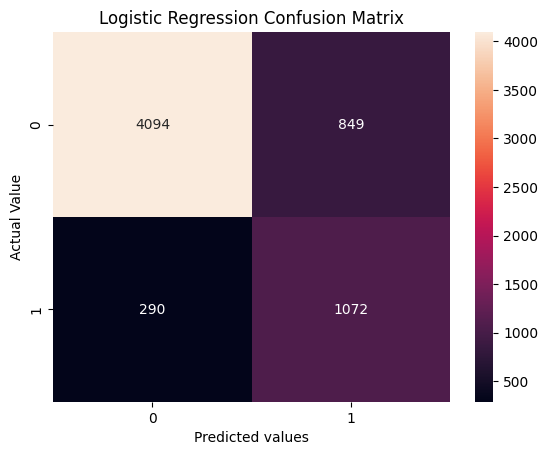

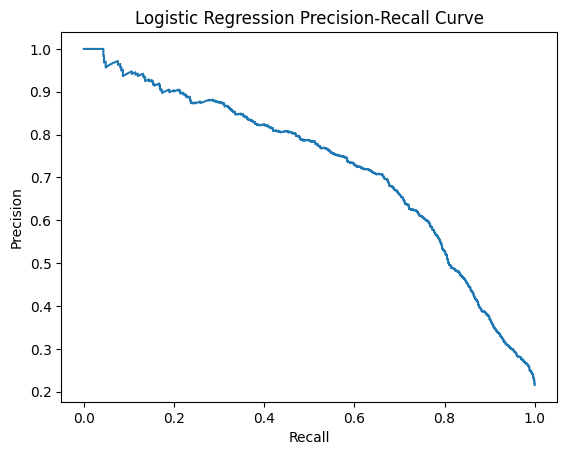

In [78]:
# Evaluate Logistic Model
evaluate_model('Logistic Regression', baseline_model, X_test, Y_test)

## 10. XGBoost hyperparameter Tuning

In [79]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weights, random_state=42))
])
xg_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [80]:
from scipy.stats import randint, uniform


In [81]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'classifier__n_estimators': randint(150,600),
    'classifier__max_depth': randint(3, 9),
    'classifier__learning_rate': uniform(0.01, 0.5),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__min_child_weight': randint(1, 10),
    'classifier__gamma': uniform(0, 5)
}

In [62]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....0014C032A5E50>, 'classifier__gamma': <scipy.stats....0014C03200640>, 'classifier__learning_rate': <scipy.stats....0014C03228C20>, 'classifier__max_depth': <scipy.stats....0014C032A5950>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the split

In [82]:
print(f"Score after Tuning: {random_search.best_score_:.2f}")

Score after Tuning: 0.90


In [83]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.9020826329350544),
 'classifier__gamma': np.float64(0.09727739373299182),
 'classifier__learning_rate': np.float64(0.08244510738804821),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 2,
 'classifier__n_estimators': 579,
 'classifier__subsample': np.float64(0.9764971587775266)}

## 11. Compare Both Models side by side

Baseline Model Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65
Baseline Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



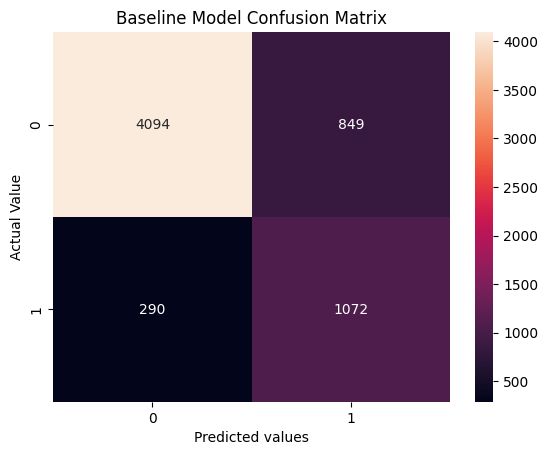

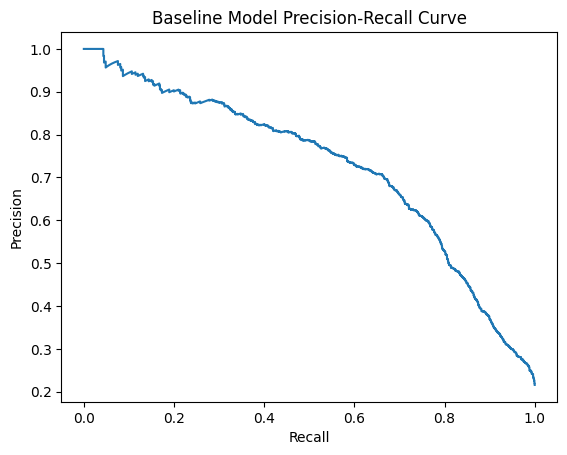

In [84]:
evaluate_model('Baseline Model', baseline_model, X_test, Y_test)

XGBoost Metrics:
Accuracy: 0.92
Precision: 0.83
Recall: 0.80
F1: 0.81
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.83      0.80      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



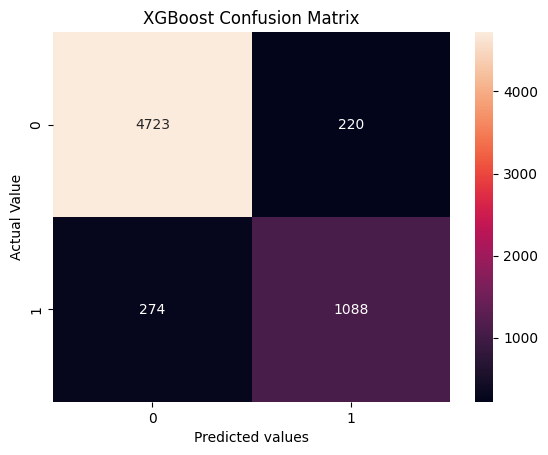

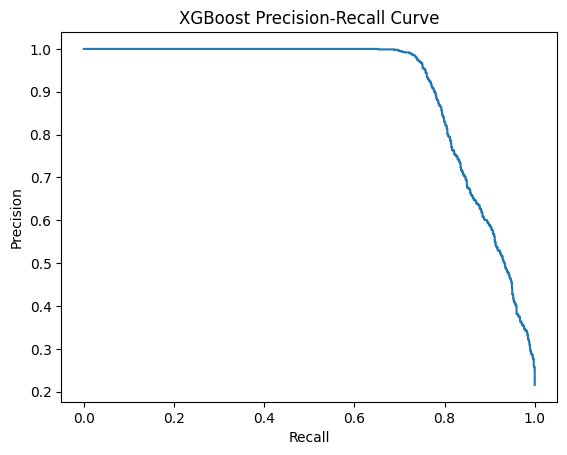

In [85]:
# passing the XGBoost model after performing Hyperparameter Tuning
evaluate_model('XGBoost', random_search, X_test, Y_test)

## 12. Optimizing the Classification Threshold

XGBoost Metrics:
Best Threshold: 0.9996131062507629
Accuracy: 0.78
Precision: 0.00
Recall: 0.00
F1: 0.00
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



C:\Users\Abhay Dixit\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhay Dixit\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Abhay Dixit\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

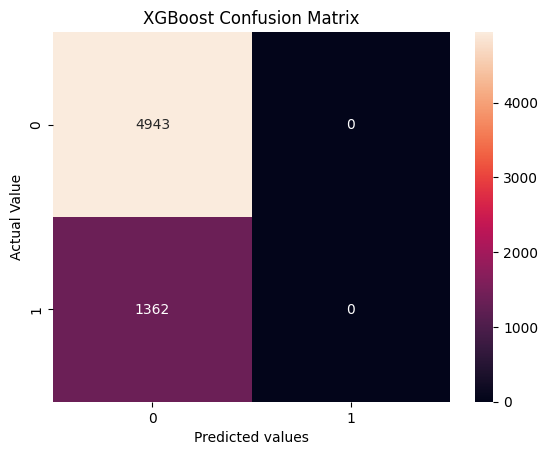

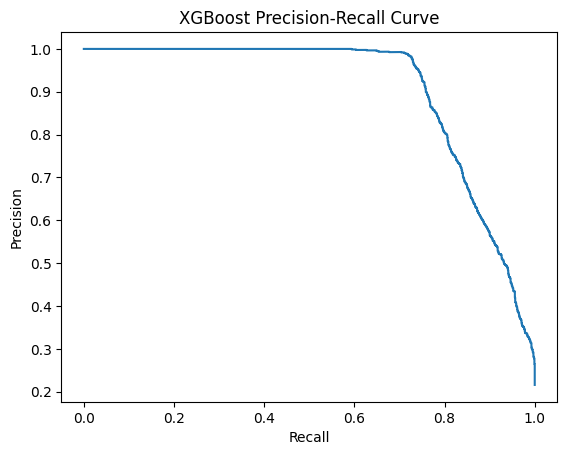

In [88]:
# Getting Probability of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For Each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(Y_test, prob)

#Calculate F1 score for each threshold
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)

#Get threshold that produce the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold
evaluate_model('XGBoost', xg_model, X_test, Y_test, best_threshold)

## 13. Probability Calibration

In [89]:
# Calibrating XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [90]:
# Getting Probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_model.predict_proba(X_test)[:, 1]

In [91]:
uncalibrated

array([0.8254656 , 0.25111562, 0.9782833 , ..., 0.48520026, 0.07587515,
       0.05467961], shape=(6305,), dtype=float32)

In [92]:
calibrated

array([0.82122759, 0.02808009, 0.95158726, ..., 0.46205272, 0.02360057,
       0.01497268], shape=(6305,))

In [93]:
# Creating Calibration Curves
actual_uncal, predicted_uncal = calibration_curve(Y_test, uncalibrated, n_bins=10)

In [94]:
actual_cal, predicted_cal = calibration_curve(Y_test, calibrated, n_bins=10)

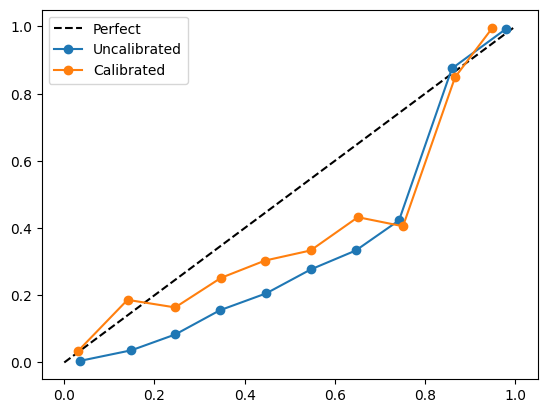

In [95]:
# Plotting
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.plot(
    predicted_uncal,
    actual_uncal,
    'o-',
    label='Uncalibrated'
)

plt.plot(
    predicted_cal,
    actual_cal,
    'o-',
    label='Calibrated'
)
plt.legend()


In [100]:
# Installing & Importing SHAP
# !pip install shap
import shap

In [101]:
# Getting Trained XGBoost classifier model out of pipeline
xgb_classifier = xg_model.named_steps['classifier']


In [102]:
# Transforming X_test using same preprocessing used for training
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)


In [103]:
# Getting feature names after one-hot encoding
feature_names= xg_model.named_steps['preprocessor'].get_feature_names_out()

In [104]:
# Converting to dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)


In [105]:
# Creating SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [106]:
# Calculating SHAP values for every row in test set
shap_values = explainer.shap_values(X_test_df)

Global Explaination

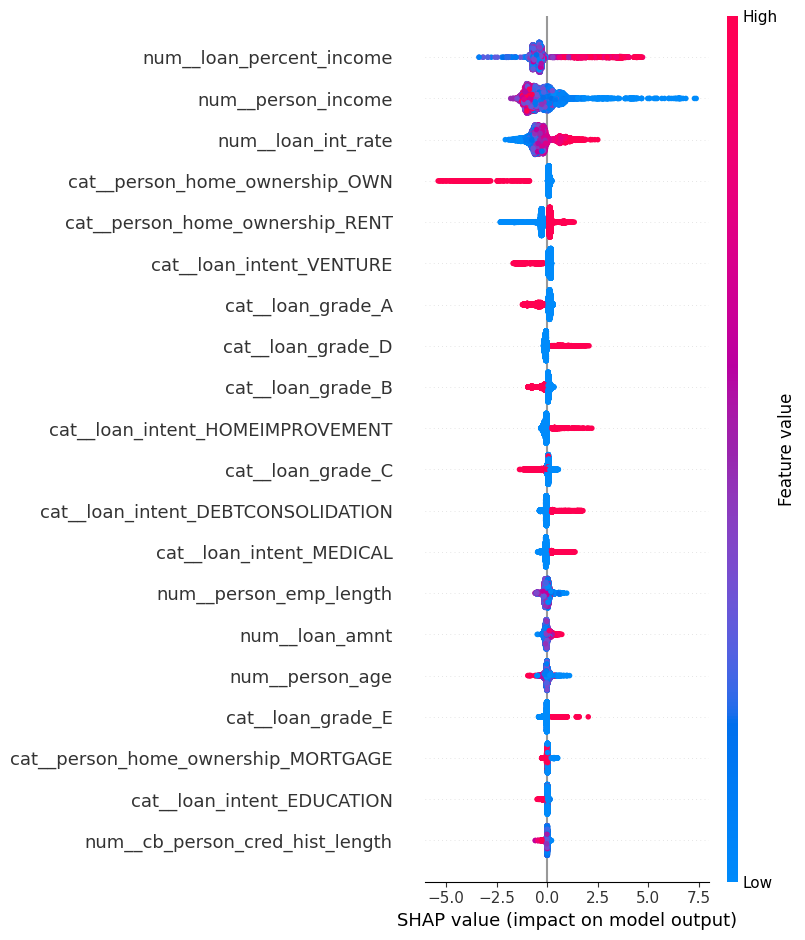

In [107]:
shap.summary_plot(shap_values, X_test_df)

Local Explaination

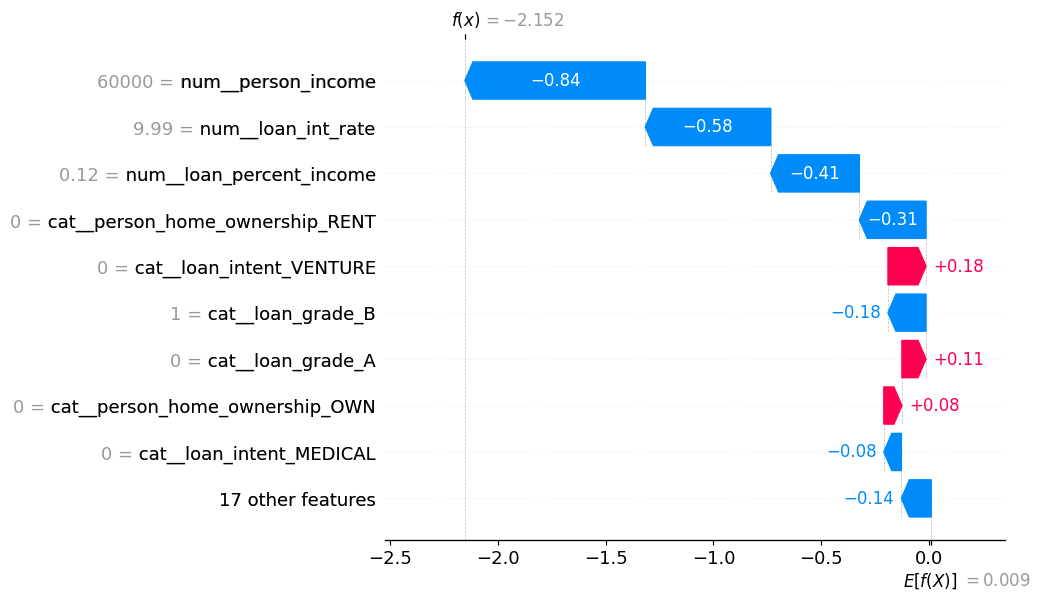

In [108]:
# Picking one row to explain, e.g 5th applicant in test set
row_index = 5

# Drafting a Waterfall plot showing how much each feature pushed prediction up or down
shap.plots.waterfall(

    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names

    )
)

## 15. Analyzing False Positives & False Negatives

False Positive -> Safe people actually marked ***Risky***


False Negative -> safe people actually marked ***Safe***

In [109]:
# Predictions from best performing XGBoost model on test set
Y_pred = random_search.predict(X_test)

In [110]:
# Creating a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = Y_test
result_df['predicted'] = Y_pred

In [111]:
# Identify False Positive:
# Model -> 1, actual -> 0
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

# Identify False Negative:
# Model -> 0, actual -> 1
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]


In [112]:
print(f'False Positive: {len(false_positive)}')
print(f'False Negative: {len(false_negative)}')

False Positive: 220
False Negative: 274


False Negative > False Positive

## 16. Saving The Model

In [113]:
import joblib
joblib.dump(calibrated_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [114]:
from sklearn.metrics import precision_recall_curve
import numpy as np

calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(Y_test, calibrated_proba)

f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_threshold = thresholds[np.argmax(f1[:-1])]

print("New Threshold: ", best_threshold)

New Threshold:  0.7751125274125402


In [115]:
joblib.dump(best_threshold, 'best_threshold.pkl')

['best_threshold.pkl']